# IRRM-CODEC: run and analyze

This notebook shows how to train from two inputs: an AIRR table and a parquet file with TCRemP embeddings.

## 1. Define inputs

The AIRR file must contain `clone_id`, `junction_aa`, `v_call`, `j_call`, `locus`.
The embeddings parquet must contain `clone_id` plus either `tcremp_emb` or numeric embedding columns.

In [1]:
from pathlib import Path

root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
airr_path = '/projects/immunestatus/vdjdb_olga/airr_format/trb_background_100k.tsv' #root / 'data' / 'sample_airr.tsv'
embeddings_path = '/projects/immunestatus/vdjdb_olga/tcremp/trb_background_100k_embeddings.parquet'
output_dir = root / 'artifacts' / 'forward_demo_trb'

airr_path, embeddings_path, output_dir

('/projects/immunestatus/vdjdb_olga/airr_format/trb_background_100k.tsv',
 '/projects/immunestatus/vdjdb_olga/tcremp/trb_background_100k_embeddings.parquet',
 PosixPath('/home/evlasova/irrm-codec/artifacts/forward_demo_trb'))

In [2]:
import sys
sys.path.insert(0, str(root))

## 2. Preview the two files

In [3]:
import pandas as pd

airr_df = pd.read_csv(airr_path, sep='\t')
emb_df = pd.read_parquet(embeddings_path)

display(airr_df.head())
display(emb_df.head())

,junction_aa,v_call,j_call,locus
0,CATSDPGTGHQPQHF,TRBV24-1,TRBJ1-5,beta
1,CAISEGLGQGETQYF,TRBV10-3,TRBJ2-5,beta
2,CASSQVGTGVYEQYF,TRBV3-1,TRBJ2-7,beta
3,CASSLGADTQYF,TRBV13,TRBJ2-3,beta
4,CASSRTGNEQYF,TRBV27,TRBJ2-7,beta


,0_b_v,0_b_j,0_b_cdr3,1_b_v,1_b_j,1_b_cdr3,2_b_v,2_b_j,2_b_cdr3,3_b_v,...,2996_b_cdr3,2997_b_v,2997_b_j,2997_b_cdr3,2998_b_v,2998_b_j,2998_b_cdr3,2999_b_v,2999_b_j,2999_b_cdr3
0,510.0,0.0,1070.0,444.0,221.0,1200.0,776.0,0.0,890.0,776.0,...,1100.0,697.0,221.0,980.0,682.0,196.0,1320.0,488.0,196.0,890.0
1,398.0,223.0,1410.0,464.0,198.0,1120.0,782.0,223.0,1070.0,782.0,...,720.0,727.0,198.0,1040.0,686.0,197.0,1460.0,428.0,197.0,1070.0
2,775.0,221.0,1330.0,709.0,0.0,820.0,423.0,221.0,990.0,423.0,...,1160.0,670.0,0.0,680.0,615.0,107.0,1080.0,765.0,107.0,730.0
3,765.0,212.0,1460.0,761.0,213.0,730.0,709.0,212.0,1200.0,709.0,...,850.0,434.0,213.0,770.0,453.0,202.0,1090.0,763.0,202.0,580.0
4,376.0,221.0,1400.0,0.0,0.0,750.0,768.0,221.0,1120.0,768.0,...,1170.0,689.0,0.0,730.0,712.0,107.0,1210.0,492.0,107.0,500.0


## 3. Launch training

In [4]:
import subprocess

cmd = [
    sys.executable, "-m", "irrm_codec.train_forward",
    "--airr-path", str(airr_path),
    "--embeddings-path", str(embeddings_path),
    "--output-dir", str(output_dir),
    "--locus", "beta",
    "--epochs", "25",
    "--lr", "3e-4",
    "--weight-decay", "1e-3",
    "--dropout", "0.2",
    "--encoder-type", "plain_conv",
    "--hidden-dim", "192",
    "--mlp-dim", "512",
    "--mlp-hidden-dim", "1024",
    "--dilations", "1,2,4,8",
    "--early-stopping-patience", "5",
    "--scheduler", "plateau",
    "--scheduler-patience", "2",
    "--scheduler-factor", "0.5",
]


subprocess.run(cmd, cwd=root, check=True)
cmd

2026-04-02 00:39:34,551 | INFO | starting forward training
2026-04-02 00:39:34,551 | INFO | output_dir=/home/evlasova/irrm-codec/artifacts/forward_demo_trb
2026-04-02 00:39:34,552 | INFO | device=cuda seed=42
2026-04-02 00:39:34,552 | INFO | hyperparameters batch_size=256 epochs=25 lr=0.000300 weight_decay=0.001000 max_len=40 encoder_type=plain_conv hidden_dim=192 mlp_dim=512 mlp_hidden_dim=1024 dropout=0.200 dilations=1,2,4,8 num_workers=0 log_interval=10 early_stopping_patience=5 scheduler=plateau
2026-04-02 00:40:08,640 | INFO | loaded data total=100000 train=80000 val=10000 test=10000 embedding_dim=9000
2026-04-02 00:40:08,640 | INFO | dataloader batches train=313 val=40 test=40
2026-04-02 00:40:08,640 | INFO | model parameters total=10406120 trainable=10406120
2026-04-02 00:40:08,643 | INFO | epoch 1/25 started
2026-04-02 00:40:15,632 | INFO | saved checkpoint path=/home/evlasova/irrm-codec/artifacts/forward_demo_trb/last.pt
2026-04-02 00:40:15,833 | INFO | new best checkpoint pat

['/home/evlasova/.conda/envs/irrm-codec/bin/python',
 '-m',
 'irrm_codec.train_forward',
 '--airr-path',
 '/projects/immunestatus/vdjdb_olga/airr_format/trb_background_100k.tsv',
 '--embeddings-path',
 '/projects/immunestatus/vdjdb_olga/tcremp/trb_background_100k_embeddings.parquet',
 '--output-dir',
 '/home/evlasova/irrm-codec/artifacts/forward_demo_trb',
 '--locus',
 'beta',
 '--epochs',
 '25',
 '--lr',
 '3e-4',
 '--weight-decay',
 '1e-3',
 '--dropout',
 '0.2',
 '--encoder-type',
 'plain_conv',
 '--hidden-dim',
 '192',
 '--mlp-dim',
 '512',
 '--mlp-hidden-dim',
 '1024',
 '--dilations',
 '1,2,4,8',
 '--early-stopping-patience',
 '5',
 '--scheduler',
 'plateau',
 '--scheduler-patience',
 '2',
 '--scheduler-factor',
 '0.5']

## 4. Inspect saved metrics and merge stats

In [5]:
import json
import pandas as pd

history = json.loads((output_dir / 'history.json').read_text())
test_metrics = json.loads((output_dir / 'test_metrics.json').read_text())
data_stats = json.loads((output_dir / 'data_stats.json').read_text())
history_df = pd.json_normalize(history)

display(history_df)
display(test_metrics)
display(data_stats)

,epoch,train.loss,train.mse,train.cosine,val.loss,val.mse,val.cosine
0,1,0.441384,0.493693,0.680671,0.325838,0.369687,0.776476
1,2,0.302752,0.343170,0.791555,0.286914,0.325879,0.804005
2,3,0.282721,0.320819,0.806173,0.283323,0.321869,0.806616
3,4,0.269798,0.306559,0.815980,0.264570,0.301636,0.821916
4,5,0.257611,0.293136,0.825283,0.245576,0.279522,0.833629
5,6,0.246813,0.280900,0.832723,0.230372,0.262028,0.843493
6,7,0.238780,0.271891,0.838479,0.229516,0.261708,0.845599
7,8,0.232690,0.265075,0.842876,0.223692,0.255439,0.850384
8,9,0.227454,0.259167,0.846543,0.217294,0.247746,0.853760
9,10,0.223954,0.255251,0.849072,0.216835,0.247466,0.854635


{'loss': 0.19281792603433132,
 'mse': 0.21993683688342572,
 'cosine': 0.8704595327377319,
 'best_checkpoint_epoch': 24,
 'best_checkpoint_val_loss': 0.1911264706403017}

{'num_samples': 100000,
 'embedding_dim': 9000,
 'num_unique_clone_ids': 100000,
 'min_length': 6,
 'max_length': 25,
 'mean_length': 13.95383,
 'truncated_fraction': 0.0,
 'unk_sequence_fraction': 0.0,
 'max_len': 40,
 'airr_rows': 100000,
 'embeddings_rows': 100000,
 'merged_rows': 100000,
 'airr_unmatched_rows': 0,
 'embeddings_unmatched_rows': 0,
 'clone_id_column': 'clone_id',
 'embedding_column': None,
 'alignment_mode': 'row_order',
 'airr_path': '/projects/immunestatus/vdjdb_olga/airr_format/trb_background_100k.tsv',
 'embeddings_path': '/projects/immunestatus/vdjdb_olga/tcremp/trb_background_100k_embeddings.parquet',
 'train_size': 80000,
 'val_size': 10000,
 'test_size': 10000,
 'standardizer': {'mean_path': 'mean.npy', 'std_path': 'std.npy'},
 'checkpoints': {'best': 'best.pt', 'last': 'last.pt'}}

<Axes: title={'center': 'Loss by epoch'}, xlabel='epoch'>

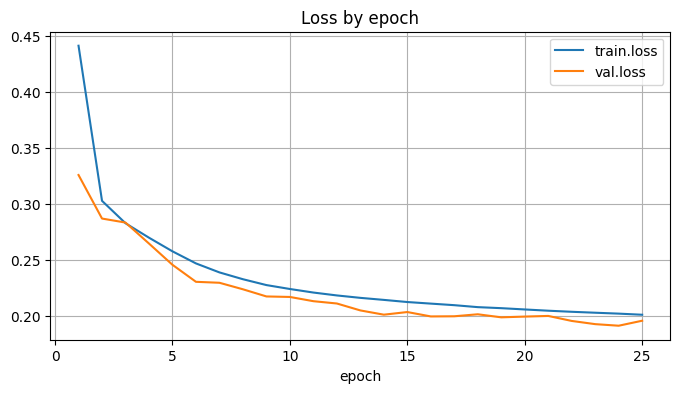

In [6]:
history_df.plot(x='epoch', y=['train.loss', 'val.loss'], figsize=(8, 4), grid=True, title='Loss by epoch')

## 5. Load a checkpoint

In [8]:
import torch
from irrm_codec.forward_model import ForwardModel

checkpoint = torch.load(output_dir / "best.pt", map_location="cpu")

extra = checkpoint["extra"]
model = ForwardModel(
    output_dim=extra["embedding_dim"],
    max_len=extra.get("max_len", 40),
    hidden_dim=extra.get("hidden_dim", 192),
    mlp_dim=extra.get("mlp_dim", 512),
    mlp_hidden_dim=extra.get("mlp_hidden_dim", 1024),
    dropout=extra.get("dropout", 0.2),
    dilations=tuple(int(x) for x in str(extra.get("dilations", "1,2,4,8")).split(",")),
    encoder_type=extra.get("encoder_type", "residual"),
)

model.load_state_dict(checkpoint["model_state"])
model.eval()

checkpoint["metrics"]


/scratch/ipykernel_3215396/120022661.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(output_dir / "best.pt", map_location="cpu")


{'loss': 0.1911264706403017,
 'mse': 0.21776539236307144,
 'cosine': 0.8710310146212578}

In [9]:
model.predict('CASSLAPGATNEKLFF')

tensor([[ 0.3008,  0.2372, -1.8493,  ...,  0.3931,  0.5525,  1.2006]])